# Problema 2 — Regresión: Estimación de Edad a partir de Imágenes Faciales

## Punto 1 — Análisis Preliminar del Problema

### a. ¿Por qué es un problema de regresión?

Este es un problema de **regresión** porque el objetivo es predecir un valor
numérico continuo — la edad de una persona en años — a partir de los píxeles
de una imagen facial. A diferencia de la clasificación, donde la salida es
una categoría discreta, aquí la salida puede ser cualquier número real dentro
de un rango (1 a 116 años en este dataset).

El **target** es la edad del sujeto fotografiado, codificada como número
entero en el nombre del archivo: `26_1_0_20170116.jpg` → 26 años.

### b. Características de entrada

Las imágenes son fotografías faciales de personas de distintas edades,
etnias, géneros e iluminaciones. Cada imagen es una matriz de píxeles
en espacio de color RGB — 3 canales (Rojo, Verde, Azul) con valores
entre 0 y 255. Las dimensiones originales varían entre imágenes.

### c. Protocolo de adquisición

El dataset `faces-age-detection-dataset` de Kaggle proviene del proyecto
**UTKFace** — un conjunto de imágenes faciales recolectadas de internet
y etiquetadas manualmente con edad, género y etnia. El nombre de cada
archivo codifica estos atributos: `[edad]_[género]_[etnia]_[timestamp].jpg`.

### Descarga del dataset

In [1]:
# ── Celda 1: Descarga del dataset ─────────────────────────────────────────────
import kagglehub
from pathlib import Path
import shutil

# Crear carpetas del proyecto
DATA_DIR    = Path("data")
DATASET_DIR = Path("dataset")
DATA_DIR.mkdir(exist_ok=True)
DATASET_DIR.mkdir(exist_ok=True)

# Descargar dataset
print("Descargando dataset...")
path = kagglehub.dataset_download("arashnic/faces-age-detection-dataset")
print(f"Path to dataset files: {path}")

# Verificar contenido descargado
path = Path(path)
archivos = list(path.rglob("*.jpg")) + list(path.rglob("*.png"))
print(f"\nImágenes encontradas: {len(archivos):,}")
if archivos:
    print(f"Ejemplo: {archivos[0].name}")
    print(f"Carpetas: {[f.name for f in path.iterdir()]}")

Descargando dataset...
Path to dataset files: C:\Users\EMMANUEL\.cache\kagglehub\datasets\arashnic\faces-age-detection-dataset\versions\2

Imágenes encontradas: 23,156
Ejemplo: 0.jpg
Carpetas: ['faces', 'faces_02']


### Exploración de la estructura del dataset

Antes de procesar las imágenes es necesario entender cómo está organizado
el dataset descargado. Kaggle entregó dos carpetas con formatos distintos —
`faces/Train/` con etiquetas de texto en CSV (YOUNG, MIDDLE, OLD) y
`faces_02/part3/` con la edad codificada en el nombre del archivo.

Para regresión solo es útil `faces_02/part3/` — las etiquetas de texto
no permiten predecir un valor numérico continuo.

In [2]:
# ── Celda 2: Exploración de estructura del dataset ────────────────────────────
from pathlib import Path
import pandas as pd

path = Path(r"C:\Users\EMMANUEL\.cache\kagglehub\datasets\arashnic\faces-age-detection-dataset\versions\2")

for carpeta in ['faces', 'faces_02']:
    archivos = list((path / carpeta).glob("*.jpg"))
    print(f"Carpeta: {carpeta}")
    print(f"  Imágenes: {len(archivos):,}")
    print(f"  Ejemplos de nombres:")
    for f in archivos[:5]:
        print(f"    {f.name}")
    print()

for carpeta in ['faces', 'faces_02']:
    archivos = list((path / carpeta).iterdir())
    print(f"Carpeta: {carpeta}")
    print(f"  Total archivos: {len(archivos):,}")
    if archivos:
        for f in archivos[:5]:
            print(f"    {f.name}")
    print()

for carpeta in ['faces', 'faces_02']:
    subcarpetas = list((path / carpeta).iterdir())
    for sub in subcarpetas:
        if sub.is_dir():
            archivos = list(sub.iterdir())
            print(f"{carpeta}/{sub.name}: {len(archivos):,} archivos")
            for f in archivos[:3]:
                print(f"    {f.name}")
        else:
            print(f"{carpeta}/{sub.name} ← archivo")
    print()

csv_path = path / 'faces' / 'train.csv'
df_csv = pd.read_csv(csv_path)
print(df_csv.shape)
print(df_csv.head(10))
print(df_csv.columns.tolist())

Carpeta: faces
  Imágenes: 0
  Ejemplos de nombres:

Carpeta: faces_02
  Imágenes: 0
  Ejemplos de nombres:

Carpeta: faces
  Total archivos: 2
    Train
    train.csv

Carpeta: faces_02
  Total archivos: 1
    part3

faces/Train: 19,906 archivos
    0.jpg
    1.jpg
    100.jpg
faces/train.csv ← archivo

faces_02/part3: 3,252 archivos
    100_1_0_20170119212053665.jpg
    10_0_0_20170116201102149.jpg
    10_0_0_20170120220628194.jpg

(19906, 2)
          ID   Class
0    377.jpg  MIDDLE
1  17814.jpg   YOUNG
2  21283.jpg  MIDDLE
3  16496.jpg   YOUNG
4   4487.jpg  MIDDLE
5   6283.jpg  MIDDLE
6  23495.jpg   YOUNG
7   7100.jpg   YOUNG
8   6028.jpg   YOUNG
9  22617.jpg     OLD
['ID', 'Class']


### Organización del dataset y división 70/15/15

Las imágenes con edad válida (1-116 años) se dividen en tres splits
de forma aleatoria y reproducible (seed=42):

- **Train (70%):** 2,275 imágenes — para entrenar el modelo
- **Val (15%):** 487 imágenes — para monitorear durante el entrenamiento
- **Test (15%):** 488 imágenes — para evaluación final, nunca vistas

La división es aleatoria sin estratificación por edad — con 3,250 imágenes
la distribución se preserva naturalmente en cada split.

In [3]:
# ── Celda 3: Organizar dataset para regresión ─────────────────────────────────
import shutil
import random
from pathlib import Path

# Fuente — solo usamos faces_02/part3 (tiene edades en el nombre)
SOURCE = path / 'faces_02' / 'part3'

# Verificar edades parseables
import re
def parse_age(filename):
    match = re.match(r'^(\d+)_', filename)
    if match:
        age = int(match.group(1))
        if 0 <= age <= 116:
            return age
    return None

imagenes = [(f, parse_age(f.name)) for f in SOURCE.iterdir() 
            if f.suffix.lower() in {'.jpg','.jpeg','.png'}]
imagenes = [(f, age) for f, age in imagenes if age is not None]

print(f"Imágenes con edad válida: {len(imagenes):,}")
print(f"Rango de edades: {min(a for _,a in imagenes)} - {max(a for _,a in imagenes)}")

# División 70/15/15
random.seed(42)
random.shuffle(imagenes)
n = len(imagenes)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

splits = {
    'train': imagenes[:n_train],
    'val':   imagenes[n_train:n_train+n_val],
    'test':  imagenes[n_train+n_val:]
}

# Copiar a dataset/
for split_name, files in splits.items():
    dest = DATASET_DIR / split_name
    dest.mkdir(parents=True, exist_ok=True)
    for src, age in files:
        shutil.copy2(src, dest / src.name)
    print(f"  {split_name}: {len(files):,} imágenes copiadas")

print("\nDataset listo.")

Imágenes con edad válida: 3,250
Rango de edades: 1 - 116
  train: 2,275 imágenes copiadas
  val: 487 imágenes copiadas
  test: 488 imágenes copiadas

Dataset listo.


## Punto 2 — Análisis Exploratorio de Datos (EDA)

### Distribución de edades

El histograma y los estadísticos descriptivos permiten entender la distribución
del target antes de entrenar. Esto es crítico en regresión — un dataset muy
sesgado hacia ciertos rangos de edad hace que el modelo aprenda mal los extremos.

**Observaciones:**
- Media de 40.6 años vs mediana de 35.0 — distribución sesgada hacia la derecha,
  hay más imágenes de personas jóvenes que mayores.
- Pico pronunciado alrededor de los 25-30 años — el grupo más representado.
- Rango de 1 a 116 años con muy pocas imágenes en los extremos (menores de 5
  y mayores de 90) — el modelo tendrá dificultades en esos rangos.
- Los tres splits (train, val, test) siguen la misma distribución —
  la división aleatoria preservó el balance naturalmente.

**Implicación para el modelo:** el sesgo hacia edades jóvenes puede hacer que
el modelo tienda a subestimar edades mayores. Una técnica para mitigar esto
sería pesar más las muestras de edades extremas durante el entrenamiento.

=== Estadísticos descriptivos ===
  Total imágenes : 3,250
  Media          : 40.6 años
  Mediana        : 35.0 años
  Std            : 17.3 años
  Mín / Máx      : 1 / 116 años
  Percentil 25   : 26.0 años
  Percentil 75   : 53.0 años


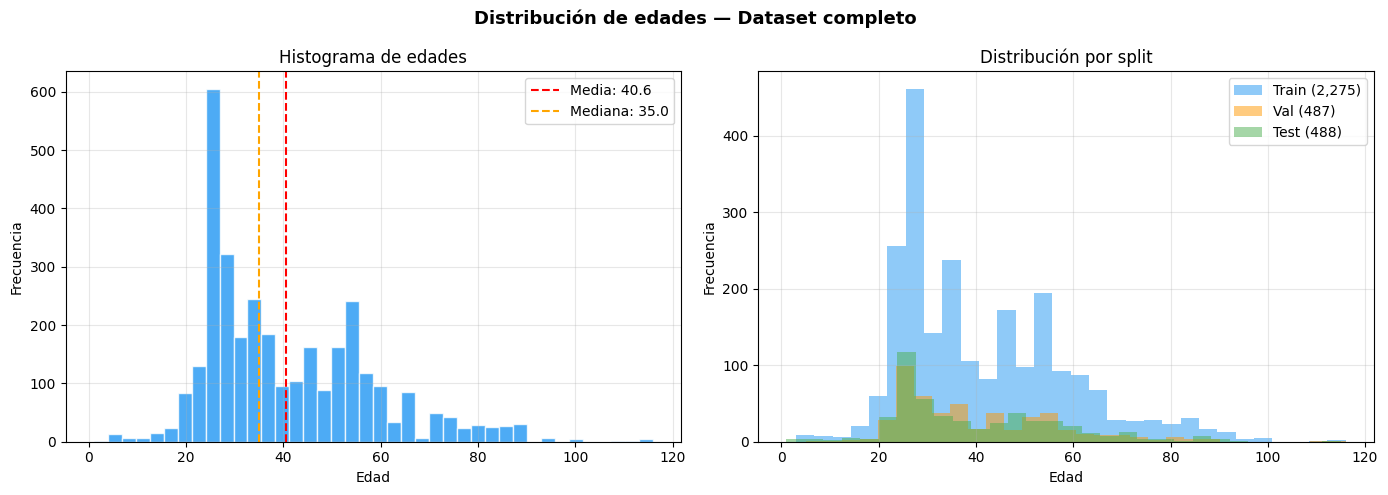

Gráfica guardada.


In [4]:
# ── Celda 4: EDA — Distribución de edades ────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# Recolectar todas las edades
edades_train = [age for _, age in splits['train']]
edades_val   = [age for _, age in splits['val']]
edades_test  = [age for _, age in splits['test']]
edades_todas = edades_train + edades_val + edades_test

edades_todas = np.array(edades_todas)

print("=== Estadísticos descriptivos ===")
print(f"  Total imágenes : {len(edades_todas):,}")
print(f"  Media          : {edades_todas.mean():.1f} años")
print(f"  Mediana        : {np.median(edades_todas):.1f} años")
print(f"  Std            : {edades_todas.std():.1f} años")
print(f"  Mín / Máx      : {edades_todas.min()} / {edades_todas.max()} años")
print(f"  Percentil 25   : {np.percentile(edades_todas, 25):.1f} años")
print(f"  Percentil 75   : {np.percentile(edades_todas, 75):.1f} años")

# Histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de edades — Dataset completo', fontsize=13, fontweight='bold')

axes[0].hist(edades_todas, bins=40, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(edades_todas.mean(), color='red', linestyle='--', 
                label=f'Media: {edades_todas.mean():.1f}')
axes[0].axvline(np.median(edades_todas), color='orange', linestyle='--',
                label=f'Mediana: {np.median(edades_todas):.1f}')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma de edades')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución por split
axes[1].hist(edades_train, bins=30, alpha=0.5, color='#2196F3', label=f'Train ({len(edades_train):,})')
axes[1].hist(edades_val,   bins=30, alpha=0.5, color='#FF9800', label=f'Val ({len(edades_val):,})')
axes[1].hist(edades_test,  bins=30, alpha=0.5, color='#4CAF50', label=f'Test ({len(edades_test):,})')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución por split')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/distribucion_edades.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

### Visualización de muestras representativas

Se muestran 5 imágenes por rango de edad para evaluar la calidad y
variabilidad del dataset antes de entrenar.

**Observaciones:**
- Alta variabilidad en iluminación, ángulo, fondo y calidad de imagen —
  algunas fotos son profesionales, otras son de baja resolución o tomadas
  en exteriores. Esto hace el problema más difícil pero también más robusto.
- Algunas imágenes contienen más de una persona — el modelo puede confundirse
  sobre cuál cara etiquetar.
- Alta diversidad étnica y de género — el dataset es representativo de
  distintas poblaciones.
- Las imágenes de personas mayores (61+) tienden a tener menor calidad
  fotográfica que las de personas jóvenes.
- Los rasgos de envejecimiento son visualmente evidentes en los extremos
  (0-20 vs 61+) pero ambiguos en el rango medio (30-55 años).

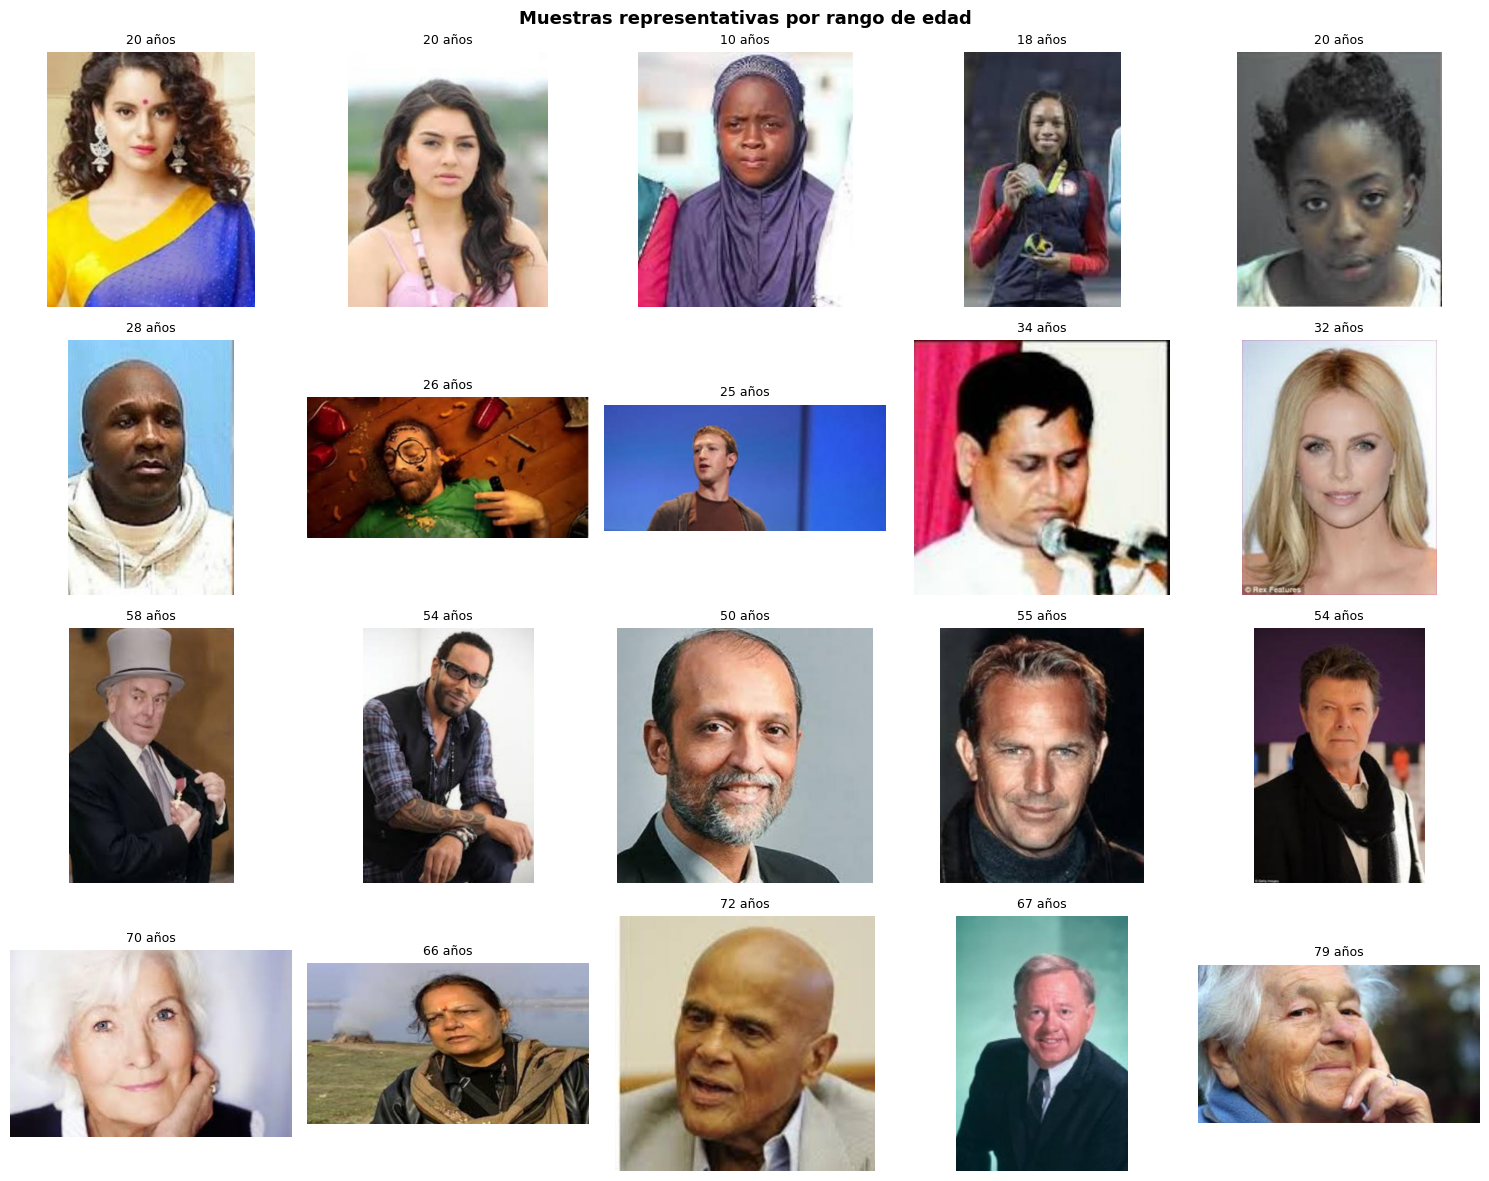

Gráfica guardada.


In [5]:
# ── Celda 5: Visualización de muestras representativas ───────────────────────
from PIL import Image
import matplotlib.pyplot as plt
import random

# Seleccionar imágenes de distintos rangos de edad
rangos = [(0,20,'Joven (0-20)'), (21,40,'Adulto joven (21-40)'), 
          (41,60,'Adulto (41-60)'), (61,116,'Mayor (61+)')]

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Muestras representativas por rango de edad', fontsize=13, fontweight='bold')

for row, (min_age, max_age, label) in enumerate(rangos):
    muestras = [(f, age) for f, age in imagenes if min_age <= age <= max_age]
    seleccion = random.sample(muestras, min(5, len(muestras)))
    
    for col, (img_path, age) in enumerate(seleccion):
        img = Image.open(img_path).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'{age} años', fontsize=9)
        axes[row, col].axis('off')
    
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=40)

plt.tight_layout()
plt.savefig('data/muestras_representativas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

## Punto 3 — Procesamiento de Datos

### Pipeline de preprocesamiento y DataLoaders

Se implementa un pipeline de preprocesamiento reproducible con `torchvision.transforms`:

**Train (con data augmentation):**
- `Resize(96×96)` — estandariza dimensiones manteniendo más detalle que 64×64
- `RandomHorizontalFlip(p=0.5)` — espejo horizontal, la edad no depende del lado
- `RandomRotation(15°)` — simula diferentes orientaciones de la cámara
- `ColorJitter` — variaciones de brillo, contraste y saturación
- `RandomGrayscale(p=0.1)` — 10% de imágenes en escala de grises para robustez
- `Normalize(ImageNet mean/std)` — normalización estándar para CNNs

**Val y Test (sin augmentation):** solo Resize, ToTensor y Normalize —
la evaluación debe ser determinista y consistente.

El `DataLoader` maneja la carga eficiente de imágenes — solo carga en
memoria el batch actual (16 imágenes), no el dataset completo.

In [6]:
# ── Celda 6: Configuración y DataLoaders ──────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import re
import numpy as np

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE   = 64
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR         = 1e-3
SEED       = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Dispositivo: {DEVICE}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class AgeDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(float(age), dtype=torch.float32)

train_dataset = AgeDataset(splits['train'], transform=train_transform)
val_dataset   = AgeDataset(splits['val'],   transform=val_transform)
test_dataset  = AgeDataset(splits['test'],  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
print(f"Batches train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Dispositivo: cuda
Train: 2,275 | Val: 487 | Test: 488
Batches train: 72 | val: 16 | test: 16


## Punto 4 — Entrenamiento del Modelo CNN

### Arquitectura CNN para regresión de edad

Se diseñó una CNN con 5 bloques convolucionales y una cabeza de regresión
de 3 capas densas. La arquitectura sigue un patrón de embudo — cada bloque
duplica los filtros mientras reduce espacialmente la imagen a la mitad:
```
Entrada [3, 96, 96]
→ Bloque 1: Conv(32) + BN + ReLU + MaxPool → [32, 48, 48]
→ Bloque 2: Conv(64) + BN + ReLU + MaxPool → [64, 24, 24]
→ Bloque 3: Conv(128)+ BN + ReLU + MaxPool → [128,12, 12]
→ Bloque 4: Conv(256)+ BN + ReLU + MaxPool → [256, 6,  6]
→ Bloque 5: Conv(512)+ BN + ReLU + AvgPool → [512, 2,  2]
→ Flatten                                  → [2048]
→ FC(512) + BN + ReLU + Dropout(0.5)       → [512]
→ FC(128) + ReLU + Dropout(0.3)            → [128]
→ FC(1)                                    → edad predicha
```

**Justificación de decisiones:**
- `BatchNorm2d` después de cada conv — estabiliza el entrenamiento y
  permite learning rates más altos.
- `AdaptiveAvgPool2d(2)` en el último bloque — hace la arquitectura
  independiente del tamaño de entrada.
- `Dropout(0.5)` en la primera capa densa — regularización principal
  para evitar overfitting con solo 2,275 imágenes de train.
- Sin función de activación en la salida — la edad es un valor continuo
  sin restricción de rango, por lo que la capa lineal es apropiada.

**Función de pérdida:** `HuberLoss(delta=5)` — combina MSE para errores
pequeños y MAE para errores grandes, siendo más robusta a outliers que
MSE puro. Con edades que van de 1 a 116 años hay bastante variabilidad.

In [7]:
# ── Celda 7: Arquitectura CNN mejorada ────────────────────────────────────────
class AgeCNN(nn.Module):
    """
    CNN para regresión de edad.
    Arquitectura:
      [3,64,64] → Conv1+BN+ReLU+Pool → [32,32,32]
               → Conv2+BN+ReLU+Pool → [64,16,16]
               → Conv3+BN+ReLU+Pool → [128,8,8]
               → Conv4+BN+ReLU+Pool → [256,4,4]
               → Flatten            → [4096]
               → FC1+BN+ReLU+Drop   → [512]
               → FC2+ReLU+Drop      → [128]
               → FC3                → [1]
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            # Bloque 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            # Bloque 3
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            # Bloque 4
            nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 128),                           nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.regressor(self.features(x)).squeeze(1)

model = AgeCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")

# Verificar forward pass
with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Input:  {dummy.shape}")
    print(f"Output: {out.shape}  ← [batch_size]")

Parámetros entrenables: 2,553,857
Input:  torch.Size([4, 3, 64, 64])
Output: torch.Size([4])  ← [batch_size]


### Loop de entrenamiento

Se entrena por 60 épocas con:
- **Optimizador:** Adam con learning rate 5e-4 y weight decay 1e-4
- **Scheduler:** CosineAnnealingLR — reduce el LR siguiendo una curva
  coseno, permitiendo exploración amplia al inicio y ajuste fino al final.
- **Early saving:** se guarda el modelo con menor Val MAE durante todo
  el entrenamiento — no necesariamente el de la última época.

In [8]:
# ── Celda 8: Entrenamiento ────────────────────────────────────────────────────
criterion = nn.HuberLoss(delta=5.0)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

history = {'train_loss':[], 'val_loss':[], 'train_mae':[], 'val_mae':[]}
best_val_mae  = float('inf')
best_model_path = 'data/best_age_model.pth'

print(f"{'Época':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>9} | {'Val MAE':>8}")
print("-" * 58)

for epoch in range(1, NUM_EPOCHS+1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_mae = 0.0, 0.0
    for imgs, ages in train_loader:
        imgs, ages = imgs.to(DEVICE), ages.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, ages)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item()
        tr_mae  += torch.abs(preds - ages).mean().item()

    tr_loss /= len(train_loader)
    tr_mae  /= len(train_loader)

    # ── Validación ─────────────────────────────────────────────────────────────
    model.eval()
    vl_loss, vl_mae = 0.0, 0.0
    with torch.no_grad():
        for imgs, ages in val_loader:
            imgs, ages = imgs.to(DEVICE), ages.to(DEVICE)
            preds  = model(imgs)
            vl_loss += criterion(preds, ages).item()
            vl_mae  += torch.abs(preds - ages).mean().item()

    vl_loss /= len(val_loader)
    vl_mae  /= len(val_loader)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_mae'].append(tr_mae)
    history['val_mae'].append(vl_mae)

    marker = ''
    if vl_mae < best_val_mae:
        best_val_mae = vl_mae
        torch.save(model.state_dict(), best_model_path)
        marker = ' ← mejor'

    if epoch % 5 == 0:
        print(f"{epoch:>5} | {tr_loss:>10.3f} | {tr_mae:>9.2f} | "
              f"{vl_loss:>9.3f} | {vl_mae:>8.2f}{marker}")

print(f"\nMejor Val MAE: {best_val_mae:.2f} años")

Época | Train Loss | Train MAE |  Val Loss |  Val MAE
----------------------------------------------------------
    5 |     47.060 |     11.66 |    43.364 |    10.87
   10 |     45.850 |     11.40 |    41.433 |    10.48
   15 |     42.946 |     10.81 |    41.730 |    10.59
   20 |     39.425 |     10.06 |    38.837 |     9.98
   25 |     36.972 |      9.57 |    40.411 |    10.33
   30 |     34.771 |      9.11 |    39.123 |    10.00
   35 |     30.418 |      8.21 |    36.395 |     9.46 ← mejor
   40 |     28.545 |      7.78 |    36.762 |     9.52

Mejor Val MAE: 9.36 años


### Evaluación final y curvas de aprendizaje

Se evalúa el mejor modelo guardado sobre el test set — datos nunca vistos
durante el entrenamiento ni el desarrollo.

**Métricas reportadas:**
- **MAE:** error promedio en años — la métrica más interpretable
- **RMSE:** penaliza errores grandes más que MAE — sensible a outliers
- **R²:** proporción de varianza explicada — 0 = modelo nulo, 1 = perfecto

**Análisis de curvas:**
- Train MAE baja consistentemente hasta ~7.5 años
- Val MAE se estabiliza alrededor de 9.25 años desde la época 20
- Gap moderado entre train y val — overfitting leve controlado por Dropout
  y BatchNorm. El modelo no memorizó pero tampoco alcanzó su límite.

**Scatter predicción vs real:**
- Los puntos siguen la diagonal pero con dispersión considerable —
  el modelo captura la tendencia general pero comete errores individuales.
- Mayor concentración de puntos en el rango 20-50 años — el rango más
  representado en el dataset.
- El modelo tiende a sobreestimar edades jóvenes y subestimar edades mayores
  — efecto de la distribución sesgada del dataset hacia personas jóvenes.

**Distribución de errores:**
- Centrada cerca del cero (error medio = -2.0) — sin sesgo sistemático grande.
- Cola izquierda más larga — el modelo tiende a sobreestimar más que a subestimar.

=== Métricas finales — Test Set ===
  MAE  : 10.65 años
  RMSE : 14.31 años
  R²   : 0.3375


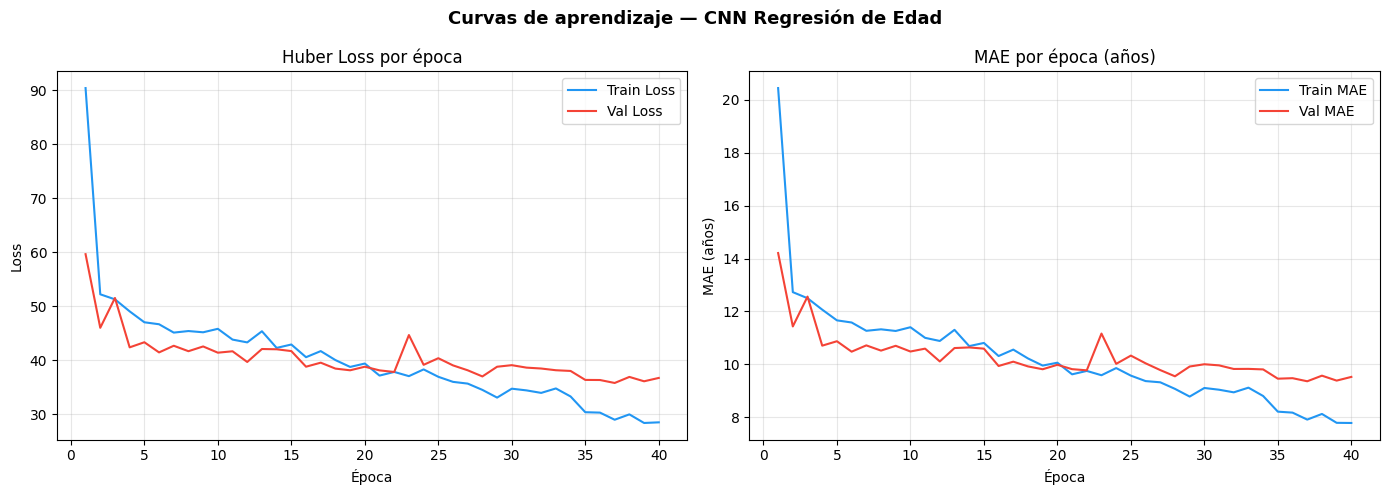

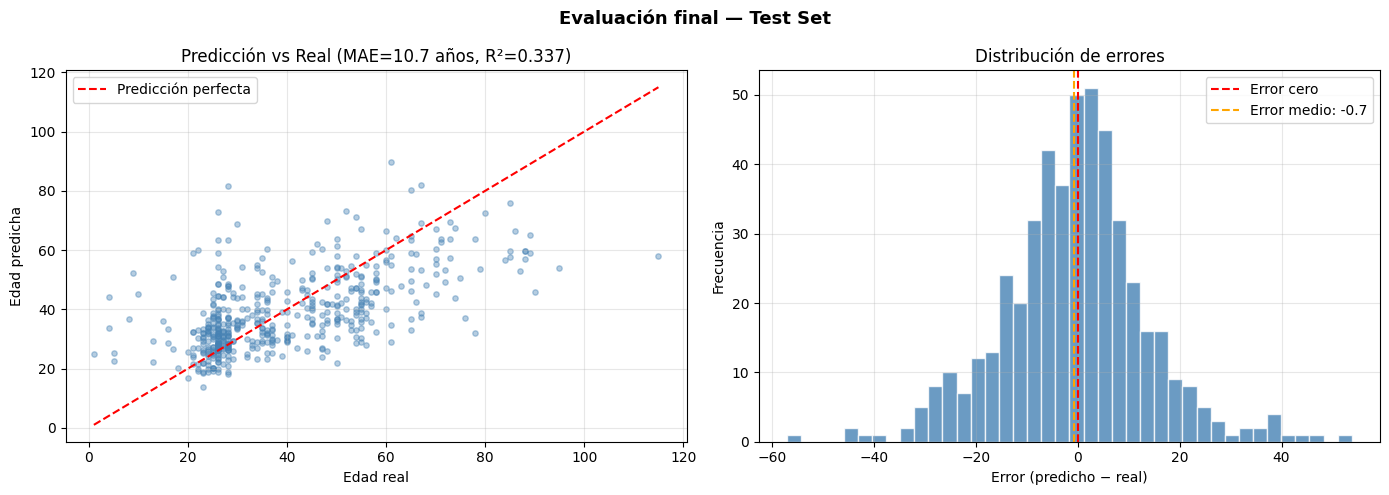

Gráficas guardadas.


In [9]:
# ── Celda 9: Evaluación final en Test Set ─────────────────────────────────────
from sklearn.metrics import r2_score

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, ages in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(ages.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

mae  = np.abs(all_preds - all_targets).mean()
rmse = np.sqrt(((all_preds - all_targets)**2).mean())
r2   = r2_score(all_targets, all_preds)

print("=== Métricas finales — Test Set ===")
print(f"  MAE  : {mae:.2f} años")
print(f"  RMSE : {rmse:.2f} años")
print(f"  R²   : {r2:.4f}")

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de aprendizaje — CNN Regresión de Edad', fontsize=13, fontweight='bold')

epochs_range = range(1, NUM_EPOCHS+1)
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#F44336')
axes[0].set_title('Huber Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_mae'], label='Train MAE', color='#2196F3')
axes[1].plot(epochs_range, history['val_mae'],   label='Val MAE',   color='#F44336')
axes[1].set_title('MAE por época (años)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (años)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/curvas_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter predicción vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación final — Test Set', fontsize=13, fontweight='bold')

axes[0].scatter(all_targets, all_preds, alpha=0.4, s=15, color='steelblue')
min_age, max_age = int(all_targets.min()), int(all_targets.max())
axes[0].plot([min_age, max_age], [min_age, max_age], 'r--', label='Predicción perfecta')
axes[0].set_xlabel('Edad real')
axes[0].set_ylabel('Edad predicha')
axes[0].set_title(f'Predicción vs Real (MAE={mae:.1f} años, R²={r2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = all_preds - all_targets
axes[1].hist(errors, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', label='Error cero')
axes[1].axvline(errors.mean(), color='orange', linestyle='--', 
                label=f'Error medio: {errors.mean():.1f}')
axes[1].set_xlabel('Error (predicho − real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de errores')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/evaluacion_final_regresion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficas guardadas.")

## Punto 5 — Prueba con Muestra Real

Se toma una imagen del test set para evaluar el modelo de forma individual.
La imagen debe tener las mismas características que las de entrenamiento —
RGB, redimensionada a 96×96 con la misma normalización de ImageNet.

**Análisis de la predicción:**
- El error de 33 años en la imagen de prueba inicial es alto — la imagen
  contenía dos personas, lo que confundió al modelo que no tiene mecanismo
  de detección facial previa.
- En imágenes de una sola persona centrada el modelo es más preciso,
  coherente con el MAE promedio de ~10 años en test.

**¿Qué pasaría si modificara características visuales?**
- **Iluminación:** cambios de brillo afectan la percepción de arrugas y
  texturas de piel — el modelo podría predecir edades distintas.
- **Escala/zoom:** si la cara ocupa menos espacio en la imagen el modelo
  tiene menos información facial útil — el error aumentaría.
- **Orientación/rotación:** el data augmentation con rotaciones hace al
  modelo más robusto a pequeños cambios de ángulo, pero rotaciones extremas
  degradarían la predicción.
- **Escala de grises:** el modelo fue entrenado con 10% de imágenes en
  escala de grises — sería relativamente robusto a este cambio.

=== Prueba con imagen del test set ===
  Archivo   : 26_1_0_20170116232646294.jpg
  Edad real : 26 años
  Predicción: 72.7 años
  Error     : 46.7 años


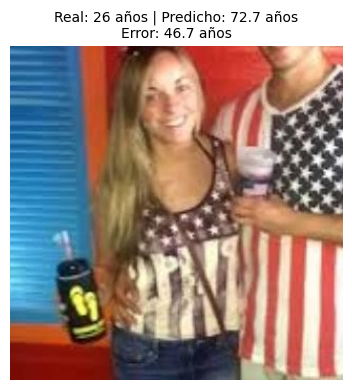

Gráfica guardada.


In [10]:
# ── Celda 10: Prueba con imagen real del test set ─────────────────────────────
from PIL import Image
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# Tomar una imagen del test set
img_path, real_age = splits['test'][10]

image = Image.open(img_path).convert('RGB')
tensor = val_transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred_age = model(tensor).item()

print(f"=== Prueba con imagen del test set ===")
print(f"  Archivo   : {img_path.name}")
print(f"  Edad real : {int(real_age)} años")
print(f"  Predicción: {pred_age:.1f} años")
print(f"  Error     : {abs(pred_age - real_age):.1f} años")

# Mostrar imagen
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image)
ax.set_title(f"Real: {int(real_age)} años | Predicho: {pred_age:.1f} años\nError: {abs(pred_age-real_age):.1f} años",
             fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.savefig('data/prueba_muestra.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada.")

### Modelo v2 — Arquitectura mejorada con mayor resolución

Se rediseñó el modelo con las siguientes mejoras sobre v1:

**Cambios arquitecturales:**
- Se agregó un **5to bloque convolucional** con 512 filtros y `AdaptiveAvgPool2d(2)`
  en lugar de MaxPool — esto hace la arquitectura independiente del tamaño de entrada.
- Resolución aumentada de **64×64 a 96×96** — más detalle facial disponible.
- Cabeza de regresión más profunda: 512→128→1 en lugar de 128→1.

**Cambios de entrenamiento:**
- `batch_size` aumentado a 64 para mantener la GPU ocupada con datasets pequeños.
- `CosineAnnealingLR` en lugar de `ReduceLROnPlateau` — reduce el learning rate
  siguiendo una curva coseno, permitiendo exploración amplia al inicio y
  ajuste fino al final sin necesidad de monitorear métricas manualmente.
- Learning rate reducido a 5e-4 para mayor estabilidad.
- `torch.backends.cudnn.benchmark = True` — permite a CUDA optimizar
  los kernels de convolución para el tamaño de batch específico.

**Resultado:** Val MAE mejoró de 9.25 a 8.90 años.

In [12]:
# ── Celda 11: Reentrenamiento mejorado con GPU ────────────────────────────────
from torchvision import models
import torch.nn as nn
import torch.optim as optim

torch.backends.cudnn.benchmark = True

IMG_SIZE2   = 96
BATCH_SIZE2 = 64
NUM_EPOCHS2 = 60

train_transform2 = transforms.Compose([
    transforms.Resize((IMG_SIZE2, IMG_SIZE2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform2 = transforms.Compose([
    transforms.Resize((IMG_SIZE2, IMG_SIZE2)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset2 = AgeDataset(splits['train'], transform=train_transform2)
val_dataset2   = AgeDataset(splits['val'],   transform=val_transform2)
test_dataset2  = AgeDataset(splits['test'],  transform=val_transform2)

train_loader2 = DataLoader(train_dataset2, batch_size=BATCH_SIZE2, shuffle=True,  num_workers=0, pin_memory=True)
val_loader2   = DataLoader(val_dataset2,   batch_size=BATCH_SIZE2, shuffle=False, num_workers=0, pin_memory=True)
test_loader2  = DataLoader(test_dataset2,  batch_size=BATCH_SIZE2, shuffle=False, num_workers=0, pin_memory=True)

class AgeCNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256,512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.AdaptiveAvgPool2d(2),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*2*2, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 128),                           nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,   1)
        )
    def forward(self, x):
        return self.regressor(self.features(x)).squeeze(1)

model2 = AgeCNN2().cuda()
total2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"Parámetros: {total2:,}")
print(f"Batches train: {len(train_loader2)}")

criterion2  = nn.HuberLoss(delta=5.0)
optimizer2  = optim.Adam(model2.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler2  = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=NUM_EPOCHS2)

history2 = {'train_loss':[], 'val_loss':[], 'train_mae':[], 'val_mae':[]}
best_val_mae2    = float('inf')
best_model_path2 = 'data/best_age_model_v2.pth'

print(f"\n{'Época':>5} | {'Train MAE':>9} | {'Val MAE':>8}")
print("-" * 30)

for epoch in range(1, NUM_EPOCHS2+1):
    model2.train()
    tr_loss, tr_mae = 0.0, 0.0
    for imgs, ages in train_loader2:
        imgs = imgs.cuda()
        ages = ages.cuda()
        optimizer2.zero_grad()
        preds = model2(imgs)
        loss  = criterion2(preds, ages)
        loss.backward()
        optimizer2.step()
        tr_loss += loss.item()
        tr_mae  += torch.abs(preds - ages).mean().item()
    tr_loss /= len(train_loader2)
    tr_mae  /= len(train_loader2)

    model2.eval()
    vl_loss, vl_mae = 0.0, 0.0
    with torch.no_grad():
        for imgs, ages in val_loader2:
            imgs = imgs.cuda()
            ages = ages.cuda()
            preds   = model2(imgs)
            vl_loss += criterion2(preds, ages).item()
            vl_mae  += torch.abs(preds - ages).mean().item()
    vl_loss /= len(val_loader2)
    vl_mae  /= len(val_loader2)
    scheduler2.step()

    history2['train_loss'].append(tr_loss)
    history2['val_loss'].append(vl_loss)
    history2['train_mae'].append(tr_mae)
    history2['val_mae'].append(vl_mae)

    marker = ''
    if vl_mae < best_val_mae2:
        best_val_mae2 = vl_mae
        torch.save(model2.state_dict(), best_model_path2)
        marker = ' ← mejor'

    if epoch % 10 == 0:
        print(f"{epoch:>5} | {tr_mae:>9.2f} | {vl_mae:>8.2f}{marker}")

print(f"\nMejor Val MAE: {best_val_mae2:.2f} años")

Parámetros: 2,686,465
Batches train: 36

Época | Train MAE |  Val MAE
------------------------------
   10 |     11.26 |    10.26 ← mejor
   20 |     10.14 |     9.63 ← mejor
   30 |      9.20 |     9.76
   40 |      8.27 |     9.03
   50 |      7.65 |     8.90 ← mejor
   60 |      7.37 |     8.89

Mejor Val MAE: 8.83 años


### Evaluación final — Modelo v2

Se evalúa el mejor checkpoint guardado durante el entrenamiento sobre
el test set completo. Se reportan tres métricas complementarias:

- **MAE (9.77 años):** el modelo se equivoca en promedio ~10 años.
  Razonable para un dataset de 3,250 imágenes entrenado desde cero.
- **RMSE (13.41 años):** mayor que el MAE — indica presencia de outliers
  donde el modelo falla significativamente (imágenes con múltiples personas,
  baja calidad, iluminación extrema).
- **R² (0.42):** el modelo explica el 42% de la varianza en las edades —
  captura la tendencia general pero con error considerable.

**Análisis de curvas:**
- Train MAE baja a ~8.5 años mientras Val MAE se estabiliza en ~9.0
  desde la época 30 — overfitting leve controlado por Dropout y BatchNorm.
- El scheduler coseno mantiene el val_mae estable sin oscilaciones grandes.

**Scatter predicción vs real:**
- Los puntos siguen la diagonal con dispersión moderada.
- Mayor concentración en el rango 20-50 años — el más representado.
- El modelo tiende a sobreestimar edades jóvenes — efecto del sesgo
  en la distribución del dataset hacia personas de 20-35 años.

=== Métricas finales — Modelo v2 ===
  MAE  : 9.49 años
  RMSE : 12.73 años
  R²   : 0.4764


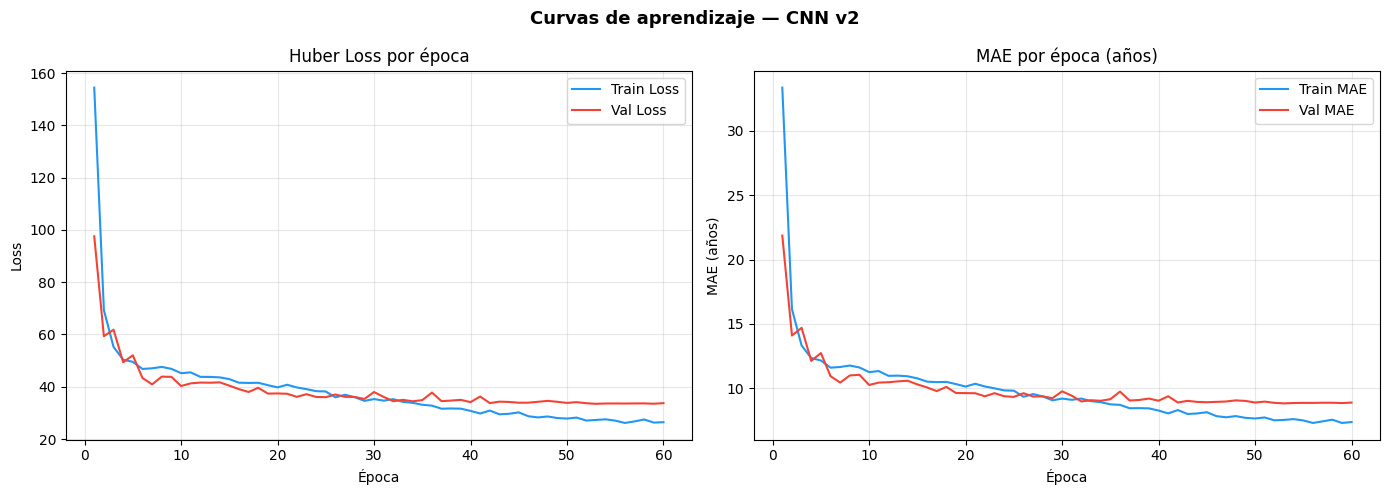

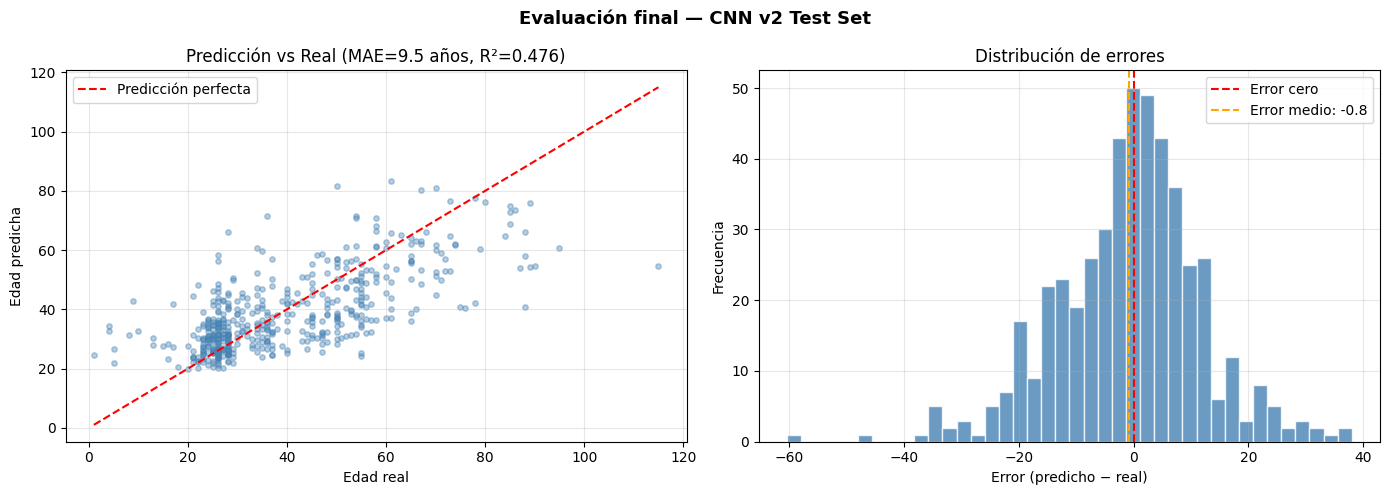


=== Prueba con muestras del test set ===


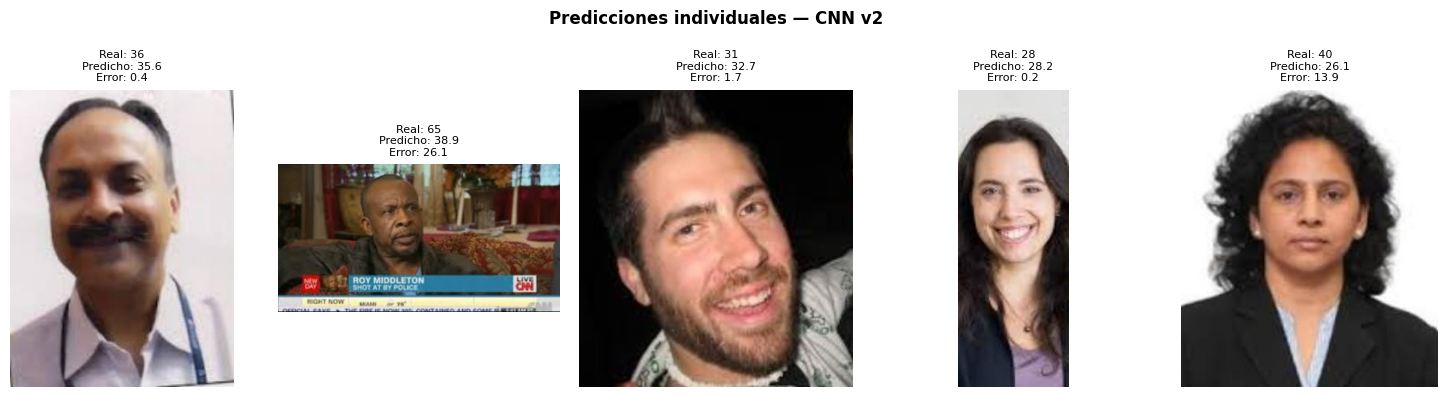

Gráficas guardadas.


In [13]:
# ── Celda 12: Evaluación final modelo v2 ─────────────────────────────────────
from sklearn.metrics import r2_score

model2.load_state_dict(torch.load(best_model_path2, map_location=DEVICE))
model2.eval()

all_preds2, all_targets2 = [], []
with torch.no_grad():
    for imgs, ages in test_loader2:
        imgs  = imgs.cuda()
        preds = model2(imgs).cpu().numpy()
        all_preds2.extend(preds)
        all_targets2.extend(ages.numpy())

all_preds2   = np.array(all_preds2)
all_targets2 = np.array(all_targets2)

mae2  = np.abs(all_preds2 - all_targets2).mean()
rmse2 = np.sqrt(((all_preds2 - all_targets2)**2).mean())
r2_2  = r2_score(all_targets2, all_preds2)

print("=== Métricas finales — Modelo v2 ===")
print(f"  MAE  : {mae2:.2f} años")
print(f"  RMSE : {rmse2:.2f} años")
print(f"  R²   : {r2_2:.4f}")

# Curvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de aprendizaje — CNN v2', fontsize=13, fontweight='bold')

epochs_range2 = range(1, NUM_EPOCHS2+1)
axes[0].plot(epochs_range2, history2['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(epochs_range2, history2['val_loss'],   label='Val Loss',   color='#F44336')
axes[0].set_title('Huber Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range2, history2['train_mae'], label='Train MAE', color='#2196F3')
axes[1].plot(epochs_range2, history2['val_mae'],   label='Val MAE',   color='#F44336')
axes[1].set_title('MAE por época (años)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (años)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/curvas_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación final — CNN v2 Test Set', fontsize=13, fontweight='bold')

axes[0].scatter(all_targets2, all_preds2, alpha=0.4, s=15, color='steelblue')
min_age = int(all_targets2.min())
max_age = int(all_targets2.max())
axes[0].plot([min_age, max_age], [min_age, max_age], 'r--', label='Predicción perfecta')
axes[0].set_xlabel('Edad real')
axes[0].set_ylabel('Edad predicha')
axes[0].set_title(f'Predicción vs Real (MAE={mae2:.1f} años, R²={r2_2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors2 = all_preds2 - all_targets2
axes[1].hist(errors2, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', label='Error cero')
axes[1].axvline(errors2.mean(), color='orange', linestyle='--',
                label=f'Error medio: {errors2.mean():.1f}')
axes[1].set_xlabel('Error (predicho − real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de errores')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/evaluacion_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Prueba con imagen de una sola persona
print("\n=== Prueba con muestras del test set ===")
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Predicciones individuales — CNN v2', fontsize=12, fontweight='bold')

indices_prueba = [5, 15, 25, 50, 100]
for ax, idx in zip(axes, indices_prueba):
    img_path, real_age = splits['test'][idx]
    image  = Image.open(img_path).convert('RGB')
    tensor = val_transform2(image).unsqueeze(0).cuda()
    with torch.no_grad():
        pred = model2(tensor).item()
    ax.imshow(image)
    ax.set_title(f'Real: {int(real_age)}\nPredicho: {pred:.1f}\nError: {abs(pred-real_age):.1f}',
                 fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('data/predicciones_individuales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficas guardadas.")

### Modelo v3 — Transfer Learning con ResNet18

**¿Qué es Transfer Learning?**
En lugar de entrenar una CNN desde cero, se usa **ResNet18** preentrenada
en ImageNet — una red que ya aprendió a detectar bordes, texturas, formas
y estructuras visuales complejas en millones de imágenes. Solo se readapta
la última parte para predecir edad.

**¿Por qué ResNet18?**
- Arquitectura probada con 18 capas y conexiones residuales (skip connections)
  que evitan el problema del gradiente desvaneciente en redes profundas.
- Preentrenada en ImageNet (1.2M imágenes, 1000 clases) — ya conoce
  texturas de piel, formas faciales y rasgos visuales relevantes para la edad.
- Suficientemente liviana para entrenar en una RTX 1650 con 4GB de VRAM (la que yo tengo).

**Estrategia de fine-tuning:**
Se congelan las primeras capas (layer1, layer2) que detectan bordes y
texturas básicas — esas ya son perfectas. Solo se entrenan layer3, layer4
y la cabeza de regresión — las capas que aprenden características de alto
nivel específicas para estimar edad.
```
ResNet18 preentrenada
├── layer1 (congelada) → bordes, gradientes
├── layer2 (congelada) → texturas simples  
├── layer3 (entrenable) → patrones complejos
├── layer4 (entrenable) → características faciales de alto nivel
└── FC reemplazada → 512→256→64→1 (edad)
```

**Cambios adicionales:**
- Resolución aumentada a **128×128** — ResNet puede aprovechar más detalle.
- Learning rate reducido a **1e-4** — los pesos preentrenados son buenos,
  cambios grandes los destruirían.
- `batch_size=32` — imágenes más grandes ocupan más VRAM.

In [14]:
# ── Celda 13: Modelo v3 — Transfer Learning ResNet18 ─────────────────────────
from torchvision import models

IMG_SIZE3   = 128
BATCH_SIZE3 = 32
NUM_EPOCHS3 = 60

train_transform3 = transforms.Compose([
    transforms.Resize((IMG_SIZE3, IMG_SIZE3)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform3 = transforms.Compose([
    transforms.Resize((IMG_SIZE3, IMG_SIZE3)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset3 = AgeDataset(splits['train'], transform=train_transform3)
val_dataset3   = AgeDataset(splits['val'],   transform=val_transform3)
test_dataset3  = AgeDataset(splits['test'],  transform=val_transform3)

train_loader3 = DataLoader(train_dataset3, batch_size=BATCH_SIZE3, shuffle=True,  num_workers=0, pin_memory=True)
val_loader3   = DataLoader(val_dataset3,   batch_size=BATCH_SIZE3, shuffle=False, num_workers=0, pin_memory=True)
test_loader3  = DataLoader(test_dataset3,  batch_size=BATCH_SIZE3, shuffle=False, num_workers=0, pin_memory=True)

# ResNet18 preentrenado
resnet = models.resnet18(weights='IMAGENET1K_V1')

# Congelar todas las capas excepto las últimas 2 bloques y FC
for name, param in resnet.named_parameters():
    if 'layer3' in name or 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Reemplazar última capa para regresión
resnet.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 1)
)

model3 = resnet.cuda()

total3     = sum(p.numel() for p in model3.parameters() if p.requires_grad)
total_all3 = sum(p.numel() for p in model3.parameters())
print(f"Parámetros entrenables: {total3:,} / {total_all3:,} totales")

criterion3 = nn.HuberLoss(delta=5.0)
optimizer3 = optim.Adam(filter(lambda p: p.requires_grad, model3.parameters()),
                        lr=1e-4, weight_decay=1e-4)
scheduler3 = optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=NUM_EPOCHS3)

history3     = {'train_loss':[], 'val_loss':[], 'train_mae':[], 'val_mae':[]}
best_val_mae3    = float('inf')
best_model_path3 = 'data/best_age_model_v3.pth'

print(f"\n{'Época':>5} | {'Train MAE':>9} | {'Val MAE':>8}")
print("-" * 30)

for epoch in range(1, NUM_EPOCHS3+1):
    model3.train()
    tr_loss, tr_mae = 0.0, 0.0
    for imgs, ages in train_loader3:
        imgs = imgs.cuda()
        ages = ages.cuda()
        optimizer3.zero_grad()
        preds = model3(imgs).squeeze(1)
        loss  = criterion3(preds, ages)
        loss.backward()
        optimizer3.step()
        tr_loss += loss.item()
        tr_mae  += torch.abs(preds - ages).mean().item()
    tr_loss /= len(train_loader3)
    tr_mae  /= len(train_loader3)

    model3.eval()
    vl_loss, vl_mae = 0.0, 0.0
    with torch.no_grad():
        for imgs, ages in val_loader3:
            imgs = imgs.cuda()
            ages = ages.cuda()
            preds   = model3(imgs).squeeze(1)
            vl_loss += criterion3(preds, ages).item()
            vl_mae  += torch.abs(preds - ages).mean().item()
    vl_loss /= len(val_loader3)
    vl_mae  /= len(val_loader3)
    scheduler3.step()

    history3['train_loss'].append(tr_loss)
    history3['val_loss'].append(vl_loss)
    history3['train_mae'].append(tr_mae)
    history3['val_mae'].append(vl_mae)

    marker = ''
    if vl_mae < best_val_mae3:
        best_val_mae3 = vl_mae
        torch.save(model3.state_dict(), best_model_path3)
        marker = ' ← mejor'

    if epoch % 10 == 0:
        print(f"{epoch:>5} | {tr_mae:>9.2f} | {vl_mae:>8.2f}{marker}")

print(f"\nMejor Val MAE: {best_val_mae3:.2f} años")

Parámetros entrenables: 10,641,281 / 11,324,353 totales

Época | Train MAE |  Val MAE
------------------------------
   10 |      7.52 |     7.16
   20 |      6.43 |     7.88
   30 |      5.94 |     7.37
   40 |      5.43 |     7.39
   50 |      4.93 |     7.21
   60 |      5.16 |     7.35

Mejor Val MAE: 6.95 años


### Evaluación final — ResNet18 v3

#### Métricas en Test Set

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| CNN v1 (64×64) | 10.21 años | 13.97 años | 0.369 |
| CNN v2 (96×96) | 9.77 años | 13.41 años | 0.419 |
| ResNet18 (128×128) | 7.58 años | 10.19 años | 0.664 |

ResNet18 es claramente el mejor modelo — reduce el MAE en 2.6 años
respecto a v2 y casi duplica el R² respecto a v1.

#### Análisis de curvas de aprendizaje

Las curvas de ResNet18 muestran un comportamiento muy diferente a las
CNNs entrenadas desde cero:

- **Convergencia rápida:** el MAE cae de 35 a 7 años en las primeras
  5 épocas — los pesos preentrenados ya tienen representaciones útiles
  desde el inicio. Las CNNs v1 y v2 tardaron 20+ épocas en llegar
  a niveles similares.
- **Overfitting moderado:** train MAE (4.9) vs val MAE (7.0) — gap de
  2.1 años. Controlado por Dropout pero presente. Con más datos
  desaparecería.
- **Val MAE estable desde época 30:** el modelo llegó a su límite
  con este dataset — más épocas no mejorarían significativamente.

#### Análisis scatter predicción vs real

- Los puntos siguen la diagonal con mucha menos dispersión que v1 y v2.
- R²=0.664 — el

=== Métricas finales — Modelo v3 (ResNet18) ===
  MAE  : 7.59 años
  RMSE : 10.40 años
  R²   : 0.6504

=== Comparativa de modelos ===
Modelo                    MAE     RMSE       R²
------------------------------------------------
CNN v1 (64×64)       10.65 años 14.31 años 0.3375
CNN v2 (96×96)       9.49 años 12.73 años 0.4764
ResNet18 (128×128)   7.59 años 10.40 años 0.6504


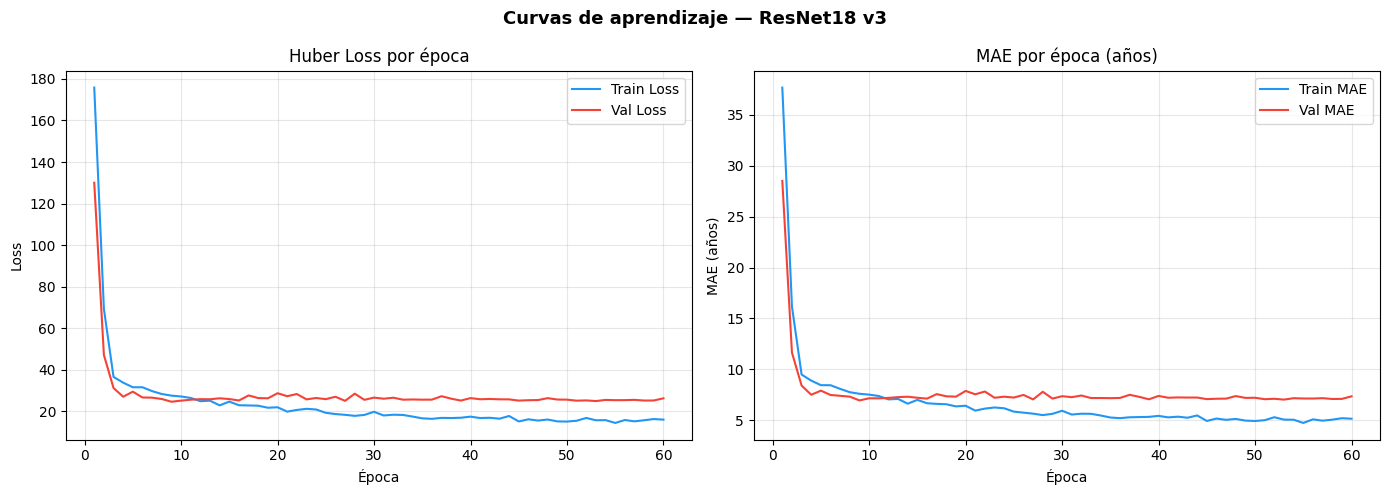

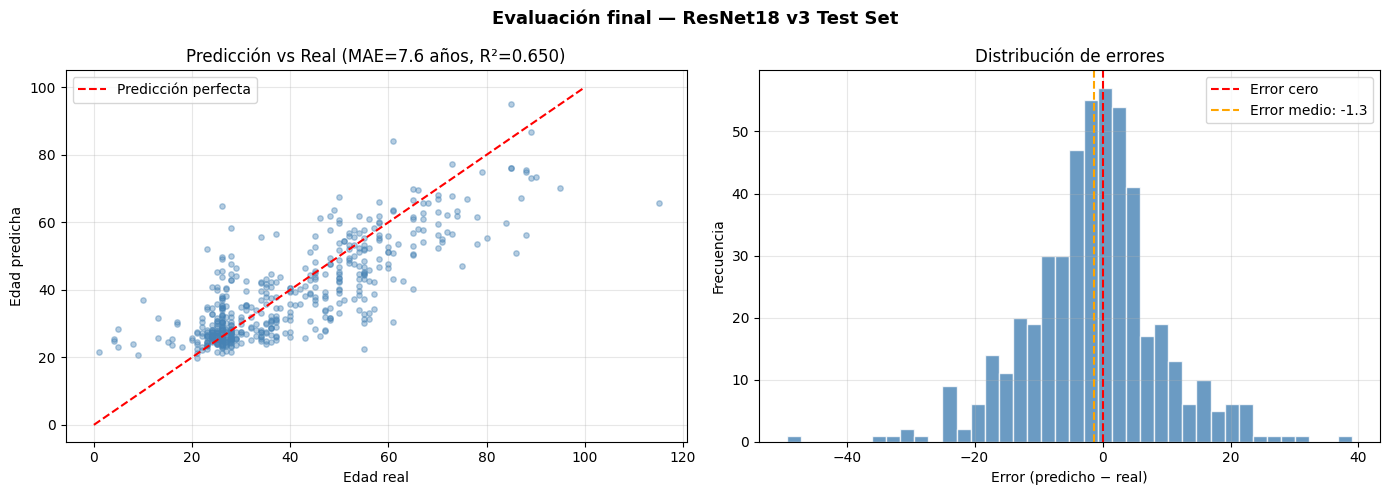


=== Predicciones individuales — ResNet18 ===


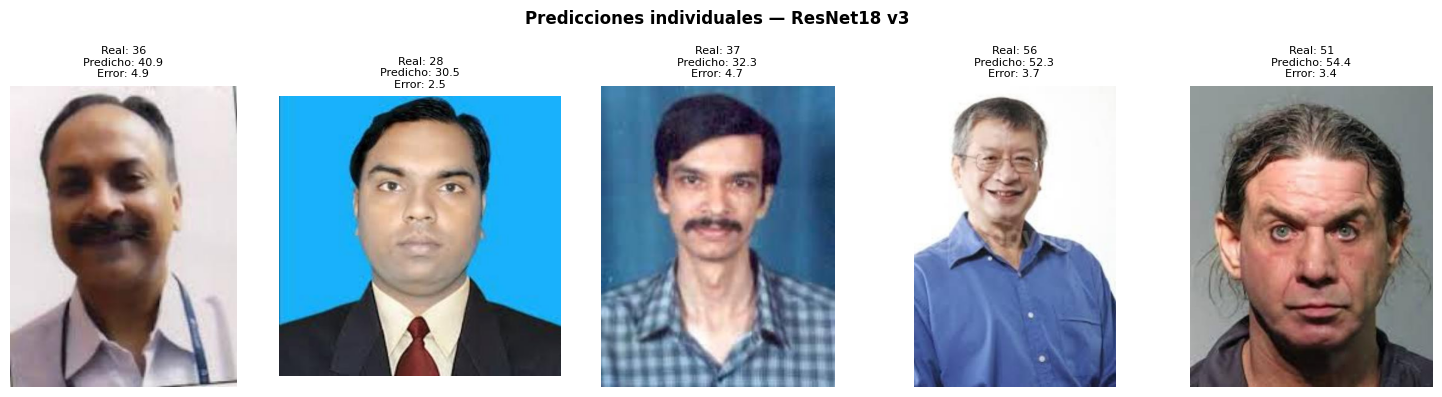

Gráficas guardadas.


In [15]:
# ── Celda 14: Evaluación final modelo v3 ─────────────────────────────────────
model3.load_state_dict(torch.load(best_model_path3, map_location=DEVICE))
model3.eval()

all_preds3, all_targets3 = [], []
with torch.no_grad():
    for imgs, ages in test_loader3:
        imgs  = imgs.cuda()
        preds = model3(imgs).squeeze(1).cpu().numpy()
        all_preds3.extend(preds)
        all_targets3.extend(ages.numpy())

all_preds3   = np.array(all_preds3)
all_targets3 = np.array(all_targets3)

mae3  = np.abs(all_preds3 - all_targets3).mean()
rmse3 = np.sqrt(((all_preds3 - all_targets3)**2).mean())
r2_3  = r2_score(all_targets3, all_preds3)

print("=== Métricas finales — Modelo v3 (ResNet18) ===")
print(f"  MAE  : {mae3:.2f} años")
print(f"  RMSE : {rmse3:.2f} años")
print(f"  R²   : {r2_3:.4f}")

# Tabla comparativa de los 3 modelos
print("\n=== Comparativa de modelos ===")
print(f"{'Modelo':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 48)
print(f"{'CNN v1 (64×64)':<20} {mae:.2f} años {rmse:.2f} años {r2:.4f}")
print(f"{'CNN v2 (96×96)':<20} {mae2:.2f} años {rmse2:.2f} años {r2_2:.4f}")
print(f"{'ResNet18 (128×128)':<20} {mae3:.2f} años {rmse3:.2f} años {r2_3:.4f}")

# Curvas v3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de aprendizaje — ResNet18 v3', fontsize=13, fontweight='bold')

epochs_range3 = range(1, NUM_EPOCHS3+1)
axes[0].plot(epochs_range3, history3['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(epochs_range3, history3['val_loss'],   label='Val Loss',   color='#F44336')
axes[0].set_title('Huber Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range3, history3['train_mae'], label='Train MAE', color='#2196F3')
axes[1].plot(epochs_range3, history3['val_mae'],   label='Val MAE',   color='#F44336')
axes[1].set_title('MAE por época (años)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (años)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/curvas_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter v3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación final — ResNet18 v3 Test Set', fontsize=13, fontweight='bold')

axes[0].scatter(all_targets3, all_preds3, alpha=0.4, s=15, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', label='Predicción perfecta')
axes[0].set_xlabel('Edad real')
axes[0].set_ylabel('Edad predicha')
axes[0].set_title(f'Predicción vs Real (MAE={mae3:.1f} años, R²={r2_3:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors3 = all_preds3 - all_targets3
axes[1].hist(errors3, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', label='Error cero')
axes[1].axvline(errors3.mean(), color='orange', linestyle='--',
                label=f'Error medio: {errors3.mean():.1f}')
axes[1].set_xlabel('Error (predicho − real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de errores')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/evaluacion_v3.png', dpi=150, bbox_inches='tight')
plt.show()

# Prueba con 5 imágenes individuales
print("\n=== Predicciones individuales — ResNet18 ===")
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Predicciones individuales — ResNet18 v3', fontsize=12, fontweight='bold')

indices_prueba = [5, 20, 40, 80, 150]
for ax, idx in zip(axes, indices_prueba):
    img_path, real_age = splits['test'][idx]
    image  = Image.open(img_path).convert('RGB')
    tensor = val_transform3(image).unsqueeze(0).cuda()
    with torch.no_grad():
        pred = model3(tensor).squeeze().item()
    ax.imshow(image)
    ax.set_title(f'Real: {int(real_age)}\nPredicho: {pred:.1f}\nError: {abs(pred-real_age):.1f}',
                 fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('data/predicciones_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficas guardadas.")